<a href="https://colab.research.google.com/github/oniviev/ml-intro-project-Nivievskyi/blob/main/Ch6_Ex11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Chapter 6 Exercise 11

11. We will now try to predict per capita crime rate in the Boston data
set.

(a) Try out some of the regression methods explored in this chapter,
such as best subset selection, the lasso, ridge regression, and
PCR. Present and discuss results for the approaches that you
consider.

In [3]:
# !pip uninstall numpy scipy ISLP -y
# !pip install numpy --upgrade
# !pip install ISLP l0bnb scipy --no-cache-dir --force-reinstall
# install ISLP 10bnb and scipy libraries
!pip install ISLP l0bnb scipy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.8/79.8 kB 2.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 66.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 30.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.6/84.6 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.4/852.4 kB 48.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 49.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 10.7 MB/s eta 0:00:00
  Created wheel for l0bnb: filename=l0bnb-1.0.0-py3-none-any.whl size=22296 sha256=41ff2ee6ac59280b1b4d0a98b0e5253953e09b1a0563f35bcec3a519fa005635
  Stored in directory: /root/.cache/pip/wheels/0e/74/8b/8a39b657554150b98e1520971211118b5137e6a1873a85f66a
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=f6

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplots
import statsmodels.api as sm

In [5]:
from sklearn.model_selection import KFold, cross_validate, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, ElasticNet, ElasticNetCV, Lasso
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
import sklearn.model_selection as skm
import sklearn.linear_model as skl
from ISLP import load_data
from ISLP.models import ModelSpec as MS
from l0bnb import fit_path
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(0)

# Ensure compatibility
np.Inf = np.inf

# 11a.1) Download Boston crime data

In [6]:
# Load the Boston dataset
boston = load_data('Boston')
print(f"Dataset shape: {boston.shape}")
print(f"Target variable: crim (per capita crime rate)")
print(f"Number of features: {boston.shape[1] - 1}")

Dataset shape: (506, 13)
Target variable: crim (per capita crime rate)
Number of features: 12


Boston data set contains housing values and other variables in 506 suburbs of Boston.

**crim**: per capita crime rate by town. \
**zn:** proportion of residential land zoned for lots over 25,000 sq.ft. \
**indus:** proportion of non-retail business acres per town.\
**chas:** Charles River dummy variable (= 1 if tract bounds river; 0 otherwise).\
**nox:** nitrogen oxides concentration (parts per 10 million). \
**rm:** average number of rooms per dwelling.\
**age:** proportion of owner-occupied units built prior to 1940. \
**dis:** weighted mean of distances to five Boston employment centres. \
**rad:** index of accessibility to radial highways. \
**tax:** full-value property-tax rate per $10,000. \

**ptratio:** pupil-teacher ratio by town. \
**lstat:** lower status of the population (percent). \
**medv:** median value of owner-occupied homes in $1000s.

In [7]:
# Prepare data - define your outcome variable y and predictors in a design matrix X
y = boston['crim']
terms = boston.columns.drop('crim')
X = MS(terms).fit_transform(boston)

# Setup cross-validation (5-fold cross-validation)
kfold = KFold(n_splits=5, shuffle=True, random_state=0)
K = 5  # number of folds

print("\nCrime Rate")
print(f"Mean: {y.mean():.3f}, Std Y: {y.std():.3f}")
print(f"Min Y: {y.min():.3f}, Max Y: {y.max():.3f}")


Crime Rate
Mean: 3.614, Std Y: 8.602
Min Y: 0.006, Max Y: 88.976


## 11a.2 : Start Comparison of Regression Methods

#### 11a.2i Linear Regression (Full model)

In [8]:
model = sm.OLS(y, X)
results = model.fit()
print("Full model summary:")
print(f"R-squared: {results.rsquared:.3f}")
print(f"Adjusted R-squared: {results.rsquared_adj:.3f}")
print(f"F-statistic p-value: {results.f_pvalue:.2e}")

# Show significant coefficients
print("\nSignificant coefficients (p < 0.05):")
coef_summary = pd.DataFrame({
    'coefficient': results.params,
    'p_value': results.pvalues
})
significant_coefs = coef_summary[coef_summary['p_value'] < 0.05]
print(significant_coefs.round(4))

Full model summary:
R-squared: 0.449
Adjusted R-squared: 0.436
F-statistic p-value: 2.03e-56

Significant coefficients (p < 0.05):
      coefficient  p_value
zn         0.0457   0.0153
dis       -1.0122   0.0004
rad        0.6125   0.0000
medv      -0.2201   0.0003


In [9]:
# print the entire summary table
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                   crim   R-squared:                       0.449
Model:                            OLS   Adj. R-squared:                  0.436
Method:                 Least Squares   F-statistic:                     33.52
Date:                Mon, 01 Jun 2026   Prob (F-statistic):           2.03e-56
Time:                        18:16:34   Log-Likelihood:                -1655.4
No. Observations:                 506   AIC:                             3337.
Df Residuals:                     493   BIC:                             3392.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     13.7784      7.082      1.946      0.0

Comments to the summary table:

Adjusted R-squared: 0.436, which is slightly lower than R-squared, accounting for the number of predictors, because usually R-squared will increase with adding more predictors.

F-statistic p-value: 2.03e-56, indicating that the model is statistically significant, i.e. all coeficients jointly are not equal to zero

Significant predictors of crime rate or coefficients (with p < 0.05), i.e. there is a statistically significant association between them and crime rate:
  - 'zn' (proportion of residential land zoned),
  - 'dis' (weighted mean of distances to employment centers),
  - 'rad' (index of accessibility to radial highways),
  - 'medv' (median value of owner-occupied homes)
  
Note: we are not talking about causality here, only about association!!!

### 11a.2ii Best Subset Selection

We now apply best subset selection to the Boston data, which for every subset size, searches for the best set of predictors.

We will use a package called l0bnb to perform best subset selection. Instead of constraining the subset to be a given size, this package produces a path of solutions using the subset size as a penalty rather than a constraint. Although the distinction is subtle, the difference comes when we cross-validate.

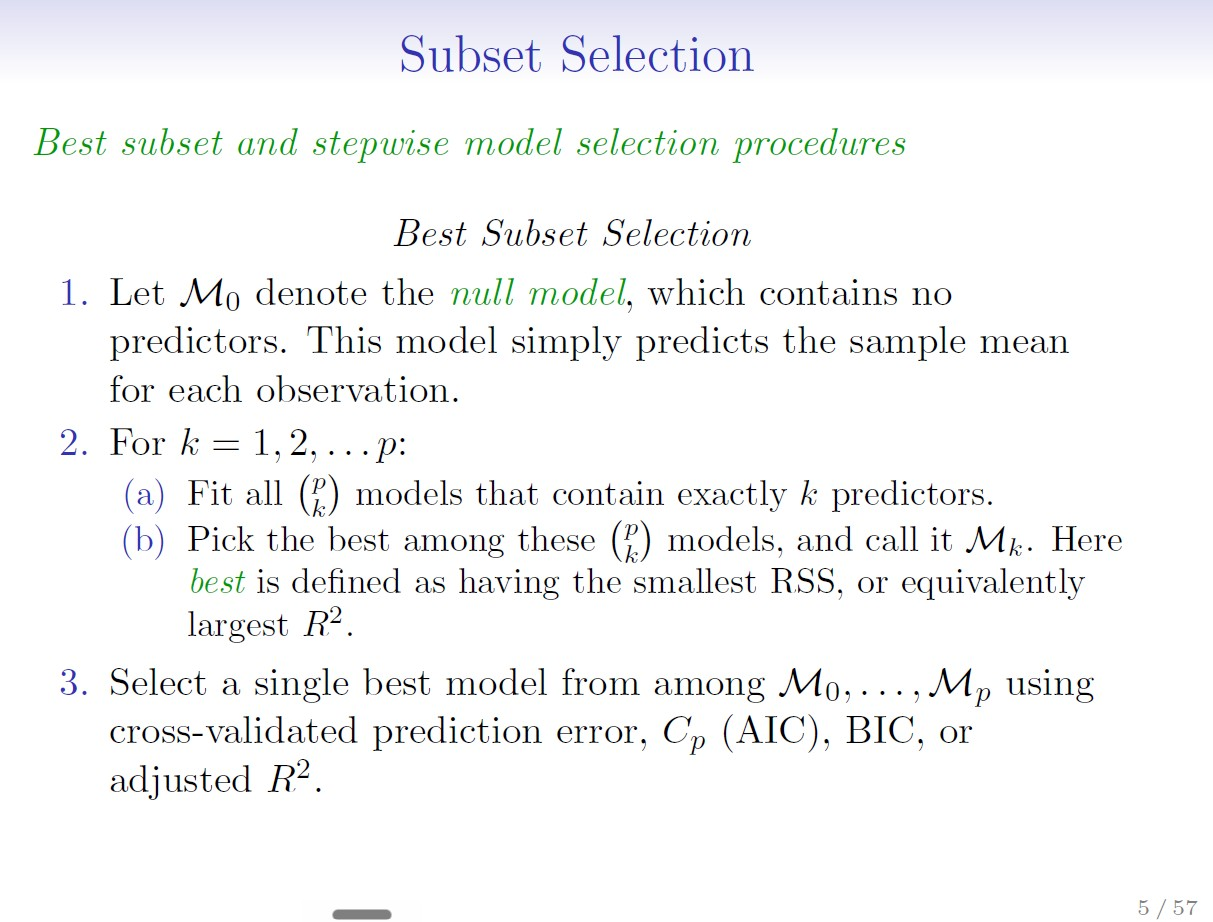

In [10]:
X_subset = X.drop('intercept', axis=1)
Y_subset = np.array(y)
X_array = np.asarray(X_subset)

# Fit path using l0bnb
print("Fitting best subset selection path...")
path = fit_path(X_array, Y_subset, max_nonzeros=X_array.shape[1])

print(f"Path computed with {len(path)} solutions")
print("Number of non-zero coefficients in path:")
for i, sol in enumerate(path):  # Show all solutions
    n_nonzero = np.sum(sol['B'] != 0)
    r2_score = sol['M']  # M is the R-squared value
    print(f"Solution {i+1}: {n_nonzero} features, R² = {r2_score:.4f}")

# Show which features are selected in the best solution (highest R²)
best_sol_idx = np.argmax([sol['M'] for sol in path])
best_sol = path[best_sol_idx]
selected_features_idx = np.where(best_sol['B'] != 0)[0]
selected_features_names = [X_subset.columns[idx] for idx in selected_features_idx]
print(f"\nBest subset solution (Solution {best_sol_idx + 1}):")
print(f"Selected features: {selected_features_names}")
print(f"Coefficients: {best_sol['B'][selected_features_idx]}")
print(f"Intercept: {best_sol['B0']:.4f}")
print(f"R²: {best_sol['M']:.4f}")

Fitting best subset selection path...
Preprocessing Data.
BnB Started.
Iteration: 1. Number of non-zeros:  1
Iteration: 2. Number of non-zeros:  2
Iteration: 3. Number of non-zeros:  4
Iteration: 4. Number of non-zeros:  8
Iteration: 5. Number of non-zeros:  10
Iteration: 6. Number of non-zeros:  12
Path computed with 6 solutions
Number of non-zero coefficients in path:
Solution 1: 1 features, R² = 0.6132
Solution 2: 2 features, R² = 0.7359
Solution 3: 4 features, R² = 0.6569
Solution 4: 8 features, R² = 0.6011
Solution 5: 10 features, R² = 0.6494
Solution 6: 12 features, R² = 0.6490

Best subset solution (Solution 2):
Selected features: ['rad', 'medv']
Coefficients: [ 0.54079338 -0.16448136]
Intercept: 2.1555
R²: 0.7359


In [ ]:
path[3]

{'B': array([ 0.04216881,  0.        , -0.92035428, -9.45405916,  0.        ,
         0.        , -0.83770967,  0.53462819,  0.        , -0.28288165,
         0.12531484, -0.16577504]),
 'B0': np.float64(13.886367023836646),
 'lambda_0': np.float64(0.0018634963087963816),
 'M': np.float64(0.60112336748906),
 'Time_exceeded': False}

 Comment:

 path[3] retrieves the fourth solution from the path object, which was generated by the fit_path function for best subset selection.

 compare to Solution 4 in the code output above that states:

 - Solution 4: 8 features, R² = 0.6011

In the example above, we see that at the fourth step in the path, we have eight nonzero features or coefficients in 'B', corresponding to the value 0.00186 for the penalty parameter lambda_0.

 In general each element in path is a dictionary representing a different model solution, typically corresponding to a different number of non-zero coefficients (features).

 Printing path[3] displays the details of that specific solution, including its coefficients, intercept, penalty parameter (lambda_0), and R-squared value.

### 11a.2iii Ridge Regression

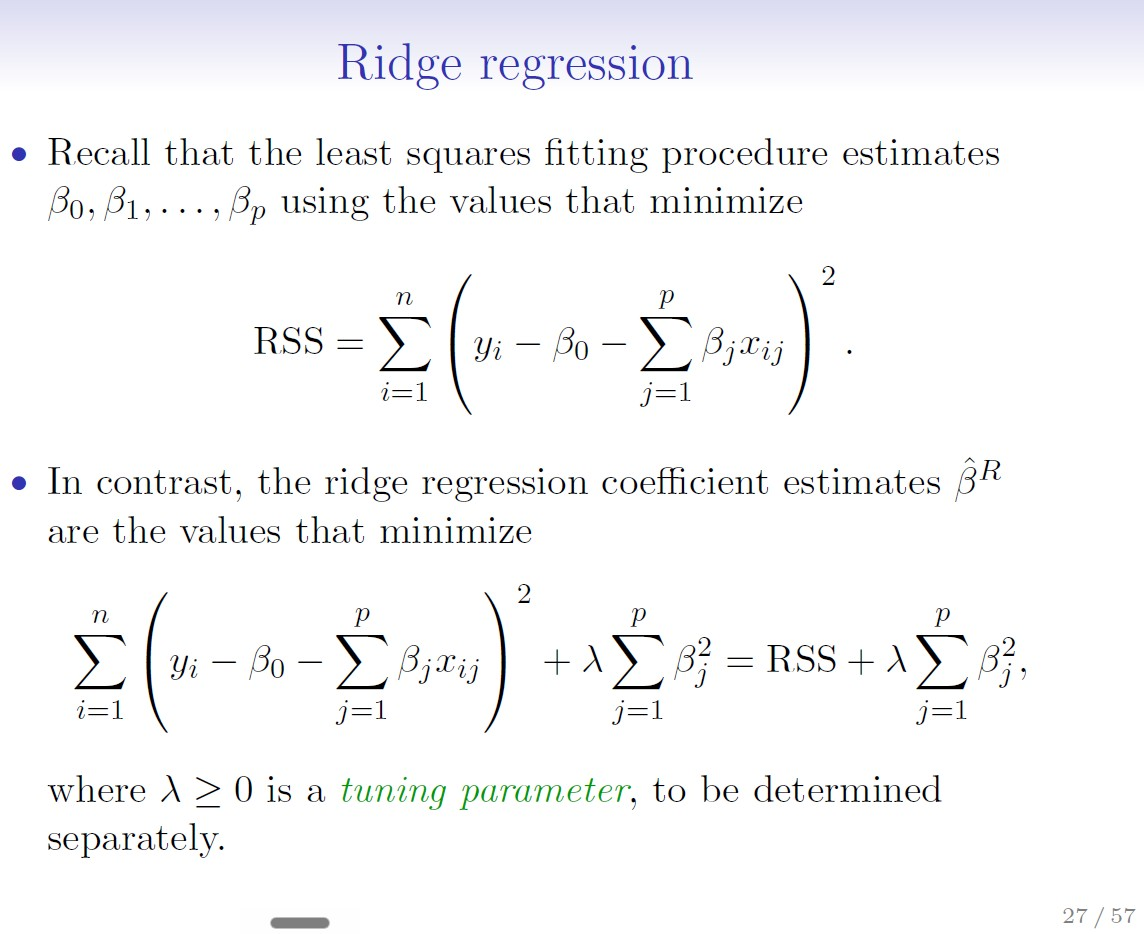

Function skl.ElasticNet() below fits both ridge and the lasso regressions. To fit a path of ridge regressions models, we use skl.ElasticNet.path(), which can fit both ridge and lasso, as well as a hybrid mixture;

ridge regression corresponds to l1_ratio=0.

It is also a good practice to standardize the columns of a desing matrix X in these applications, if the variables are measured in different units.

Since skl.ElasticNet() does no normalization, we have to take care of that ourselves. Since we standardize first, in order to find coefficient estimates on the original scale, we must unstandardize the coefficient estimates.

In [11]:
scaler = StandardScaler()
lambdas = 10**np.linspace(8, -2, 100) / y.std()

# Manual standardization for path plotting
X_no_intercept = X.drop('intercept', axis=1)
means = X_no_intercept.mean()
stds  = X_no_intercept.std()
Xs = (X_no_intercept - means) / stds

# Compute ridge path
soln_array = skl.ElasticNet.path(Xs, Y_subset, l1_ratio=0., alphas=lambdas)[1]
soln_path = pd.DataFrame(soln_array.T,
                         columns=X_no_intercept.columns,
                         index=-np.log(lambdas))
soln_path.index.name = 'negative log(lambda)'

print(f"Ridge path computed with {len(lambdas)} lambda values")
print(f"Lambda range: {lambdas.min():.2e} to {lambdas.max():.2e}")

# Fit Ridge with cross-validation
ridgeCV = skl.ElasticNetCV(alphas=lambdas, l1_ratio=0, cv=kfold)
pipeCV_ridge = Pipeline(steps=[('scaler', scaler), ('ridge', ridgeCV)])
pipeCV_ridge.fit(X_no_intercept, y)

tuned_ridge = pipeCV_ridge.named_steps['ridge']
print(f"Best lambda (Ridge): {tuned_ridge.alpha_:.4f}")
print(f"Best CV MSE (Ridge): {np.min(tuned_ridge.mse_path_.mean(1)):.1f}")

Ridge path computed with 100 lambda values
Lambda range: 1.16e-03 to 1.16e+07
Best lambda (Ridge): 0.0047
Best CV MSE (Ridge): 42.9


We plot the paths to get a sense of how the coefficients vary with λ. To control the location of the legend we first set legend to False in the plot method, adding it afterward with the legend() method of ax.

Each colored line represents how the standardized coefficient of a particular predictor variable changes as the regularization strength (lambda, on the x-axis, represented as -log(lambda)) varies.

The Best lambda value (0.0047) determined by cross-validation, which minimizes the cross-validated mean squared error. As you move from left to right (decreasing lambda, meaning less regularization), you can observe the coefficients moving away from zero, and some may change their signs or magnitudes significantly.

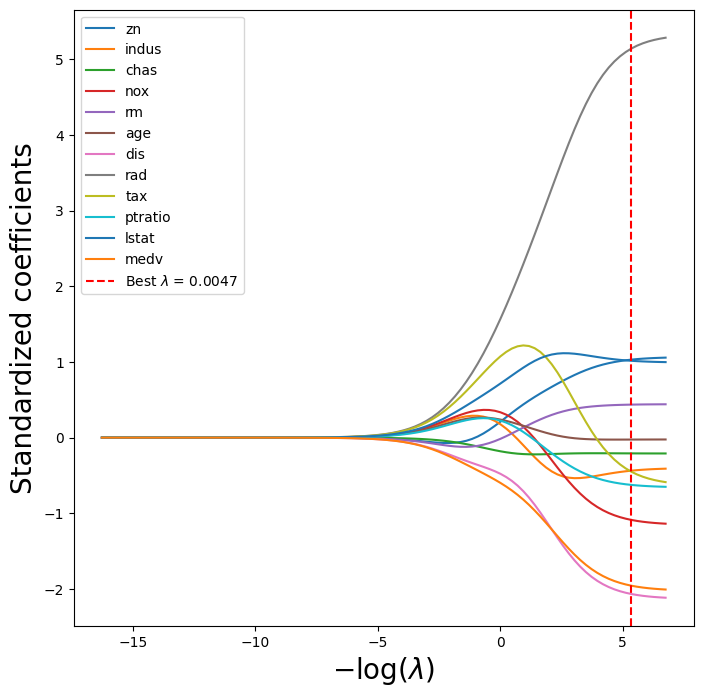

In [12]:
path_fig, ax = subplots(figsize=(8,8))
soln_path.plot(ax=ax, legend=False)
ax.axvline(-np.log(tuned_ridge.alpha_), color='red', linestyle='--', label=f'Best $\lambda$ = {tuned_ridge.alpha_:.4f}')
ax.set_xlabel('$-\log(\lambda)$', fontsize=20)
ax.set_ylabel('Standardized coefficients', fontsize=20)
ax.legend(loc='upper left');

### 11a.2iv Lasso Regression

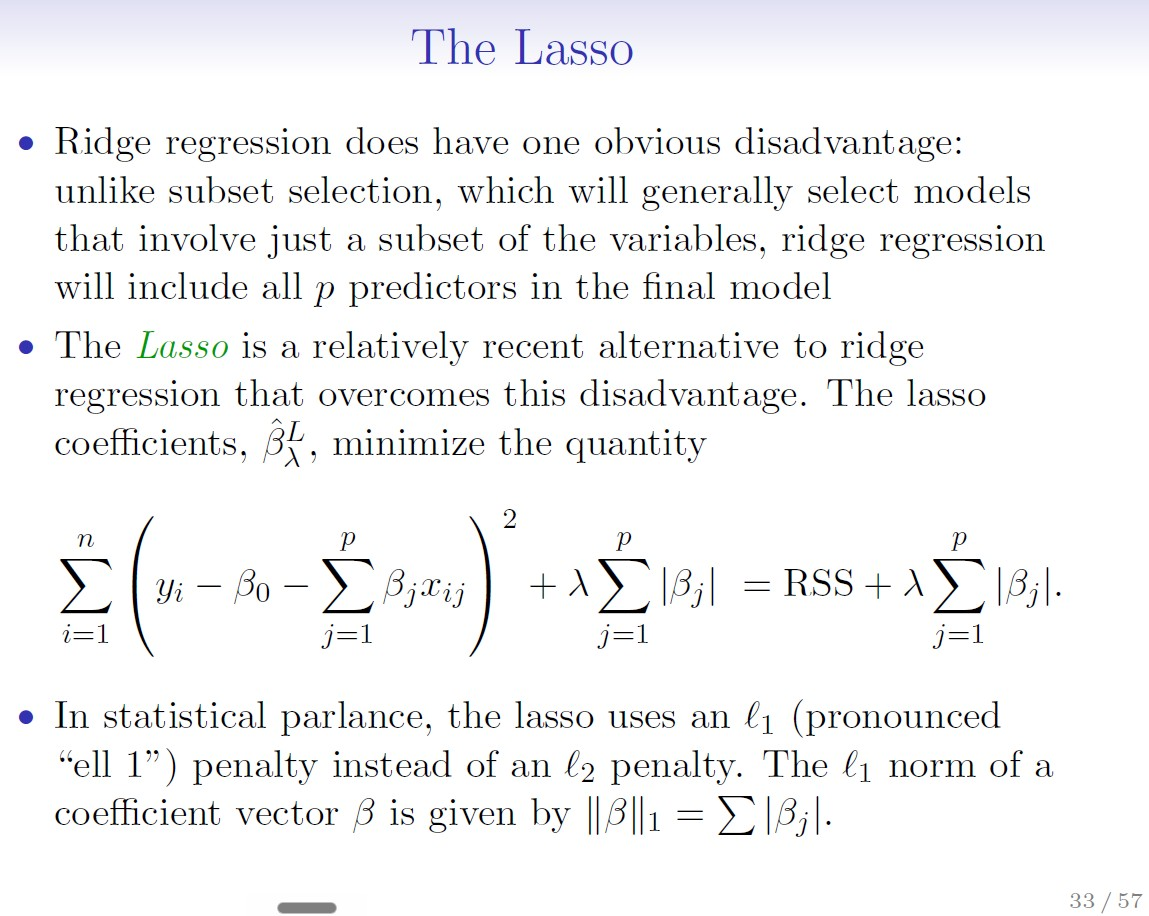

In [13]:
lassoCV = skl.ElasticNetCV(n_alphas=100, l1_ratio=1, cv=kfold)
pipeCV_lasso = Pipeline(steps=[('scaler', scaler), ('lasso', lassoCV)])
pipeCV_lasso.fit(X_no_intercept, y)

tuned_lasso = pipeCV_lasso.named_steps['lasso']
print(f"Best lambda (Lasso): {tuned_lasso.alpha_:.4f}")
print(f"Best CV MSE (Lasso): {np.min(tuned_lasso.mse_path_.mean(1)):.1f}")

# Compute Lasso path for plotting
lambdas_lasso, soln_array_lasso = skl.Lasso.path(Xs, Y_subset, n_alphas=100)[:2]
soln_path_lasso = pd.DataFrame(soln_array_lasso.T,
                               columns=X_no_intercept.columns,
                               index=-np.log(lambdas_lasso))

# Count selected features
final_coefs = tuned_lasso.coef_
n_selected = np.sum(np.abs(final_coefs) > 1e-6)
print(f"Number of selected features: {n_selected} out of {len(final_coefs)}")

# Show selected features
selected_features = X_no_intercept.columns[np.abs(final_coefs) > 1e-6]
print(f"Selected features: {list(selected_features)}")

Best lambda (Lasso): 0.0501
Best CV MSE (Lasso): 42.8
Number of selected features: 10 out of 12
Selected features: ['zn', 'indus', 'chas', 'nox', 'rm', 'dis', 'rad', 'ptratio', 'lstat', 'medv']


Visualize the Lasso regularization path similar to the Ridge plot

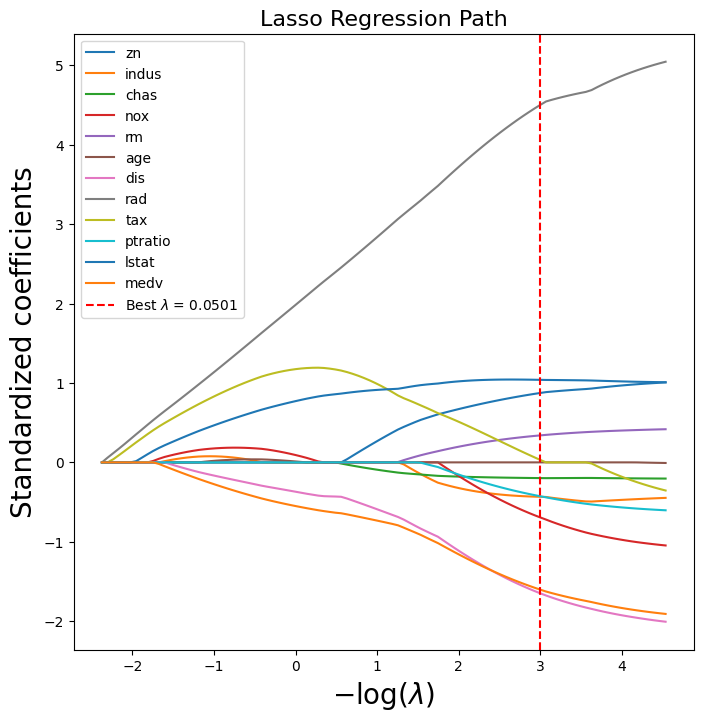

In [14]:
fig, ax = subplots(figsize=(8,8))
soln_path_lasso.plot(ax=ax, legend=False)
ax.axvline(-np.log(tuned_lasso.alpha_), color='red', linestyle='--', label=f'Best $\lambda$ = {tuned_lasso.alpha_:.4f}')
ax.set_xlabel('$-\log(\lambda)$', fontsize=20)
ax.set_ylabel('Standardized coefficients', fontsize=20)
ax.set_title('Lasso Regression Path', fontsize=16)
ax.legend(loc='upper left')

### 11a.2v Principal Component Regression

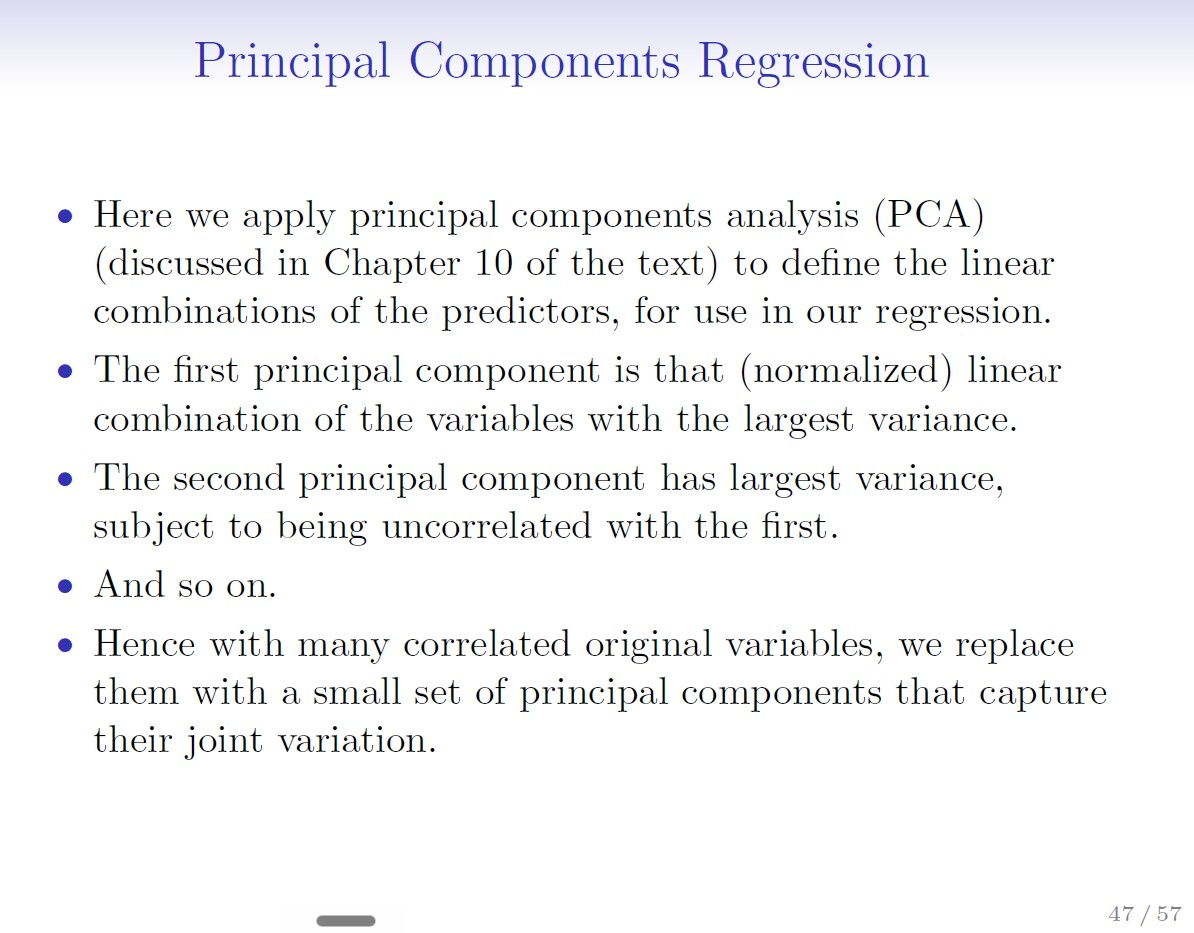

In [15]:
pca = PCA()
linreg = skl.LinearRegression()
pipe_pcr = Pipeline([('scaler', scaler), ('pca', pca), ('linreg', linreg)])

# Grid search for best number of components
param_grid = {'pca__n_components': range(1, len(X_no_intercept.columns) + 1)}
grid_pcr = skm.GridSearchCV(pipe_pcr, param_grid, cv=kfold, scoring='neg_mean_squared_error')
grid_pcr.fit(X_no_intercept, y)

print(f"Best number of components: {grid_pcr.best_params_['pca__n_components']}")
print(f"Best CV MSE (PCR): {-grid_pcr.best_score_:.1f}")

Best number of components: 12
Best CV MSE (PCR): 42.9


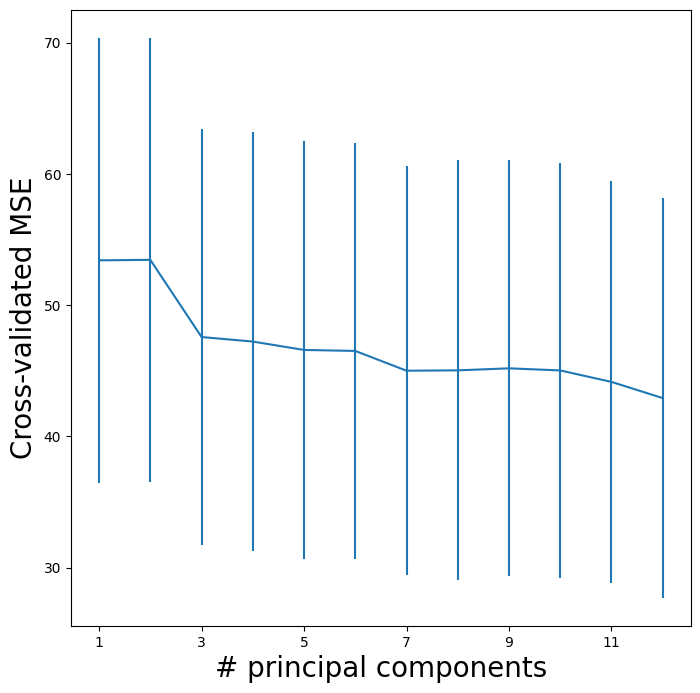

In [16]:
pcr_fig, ax = subplots(figsize=(8,8))
n_comp = param_grid['pca__n_components']
ax.errorbar(n_comp,
            -grid_pcr.cv_results_['mean_test_score'],
            grid_pcr.cv_results_['std_test_score'] / np.sqrt(K))
ax.set_ylabel('Cross-validated MSE', fontsize=20)
ax.set_xlabel('# principal components', fontsize=20)
ax.set_xticks(n_comp[::2]);
#ax.set_ylim([50000,250000]);

(b) Propose a model (or set of models) that seem to perform well on
this data set, and justify your answer. Make sure that you are
evaluating model performance using validation set error, crossvalidation,
or some other reasonable alternative, as opposed to
using training error.

## Cross Validation (for each method)

In [17]:
# Initialize results storage
methods = ['Linear Regression', 'Best Subset Selection', 'Ridge Regression', 'Lasso Regression', 'PCR']
cv_errors = np.zeros(len(methods))

print("Computing cross-validation errors...")

# Cross-validation loop for each method
cv = KFold(n_splits=5, shuffle=True, random_state=0)

# Add null model for comparison
Xn = np.zeros((X_no_intercept.shape[0], 1))
cv_null = cross_validate(LinearRegression(), Xn, y, cv=cv, scoring='neg_mean_squared_error')
null_mse = -np.mean(cv_null['test_score'])

print(f"\nNull model (intercept only) CV MSE: {null_mse:.2f}")

for i, method in enumerate(methods):
    if method == 'Linear Regression':
        # Simple linear regression
        model_lr = LinearRegression()
        cv_results = cross_validate(model_lr, X_no_intercept, y, cv=cv, scoring='neg_mean_squared_error')
        cv_errors[i] = -np.mean(cv_results['test_score'])

    elif method == 'Best Subset Selection':
        # For best subset, we'll use the best solution from the path and evaluate it with CV
        # This is a simplified approach - ideally we'd do subset selection within each CV fold
        best_features_idx = np.where(best_sol['B'] != 0)[0]
        if len(best_features_idx) > 0:
            X_selected = X_no_intercept.iloc[:, best_features_idx]
            model_subset = LinearRegression()
            cv_results = cross_validate(model_subset, X_selected, y, cv=cv, scoring='neg_mean_squared_error')
            cv_errors[i] = -np.mean(cv_results['test_score'])
        else:
            cv_errors[i] = null_mse  # If no features selected, use null model performance

    elif method == 'Ridge Regression':
        # Ridge with nested CV for lambda selection
        inner_cv = KFold(n_splits=5, shuffle=True, random_state=2)
        ridgeCV_nested = skl.ElasticNetCV(alphas=lambdas, l1_ratio=0, cv=inner_cv)
        pipe_ridge = Pipeline(steps=[('scaler', StandardScaler()), ('ridge', ridgeCV_nested)])
        cv_results = cross_validate(pipe_ridge, X_no_intercept, y, cv=cv, scoring='neg_mean_squared_error')
        cv_errors[i] = -np.mean(cv_results['test_score'])

    elif method == 'Lasso Regression':
        # Lasso with nested CV for lambda selection
        inner_cv = KFold(n_splits=5, shuffle=True, random_state=2)
        lassoCV_nested = skl.ElasticNetCV(n_alphas=100, l1_ratio=1, cv=inner_cv)
        pipe_lasso = Pipeline(steps=[('scaler', StandardScaler()), ('lasso', lassoCV_nested)])
        cv_results = cross_validate(pipe_lasso, X_no_intercept, y, cv=cv, scoring='neg_mean_squared_error')
        cv_errors[i] = -np.mean(cv_results['test_score'])

    elif method == 'PCR':
        # PCR with nested CV for component selection
        inner_cv = KFold(n_splits=5, shuffle=True, random_state=2)
        param_grid_nested = {'pca__n_components': range(1, len(X_no_intercept.columns) + 1)}
        pipe_pcr_nested = Pipeline([('scaler', StandardScaler()), ('pca', PCA()), ('linreg', LinearRegression())])
        grid_nested = GridSearchCV(pipe_pcr_nested, param_grid_nested, cv=inner_cv, scoring='neg_mean_squared_error')
        cv_results = cross_validate(grid_nested, X_no_intercept, y, cv=cv, scoring='neg_mean_squared_error')
        cv_errors[i] = -np.mean(cv_results['test_score'])

# Create results summary
results_summary = pd.DataFrame({
    'Method': methods,
    'CV MSE': cv_errors
}).sort_values('CV MSE')

print(results_summary.round(2))

# Find best method
best_method = results_summary.iloc[0]['Method']
best_mse = results_summary.iloc[0]['CV MSE']

print(f"\nBest Method: {best_method}")
print(f"Best CV MSE: {best_mse:.2f}")

Computing cross-validation errors...

Null model (intercept only) CV MSE: 74.12
                  Method  CV MSE
3       Lasso Regression   42.78
0      Linear Regression   42.92
4                    PCR   42.92
2       Ridge Regression   42.98
1  Best Subset Selection   44.33

Best Method: Lasso Regression
Best CV MSE: 42.78


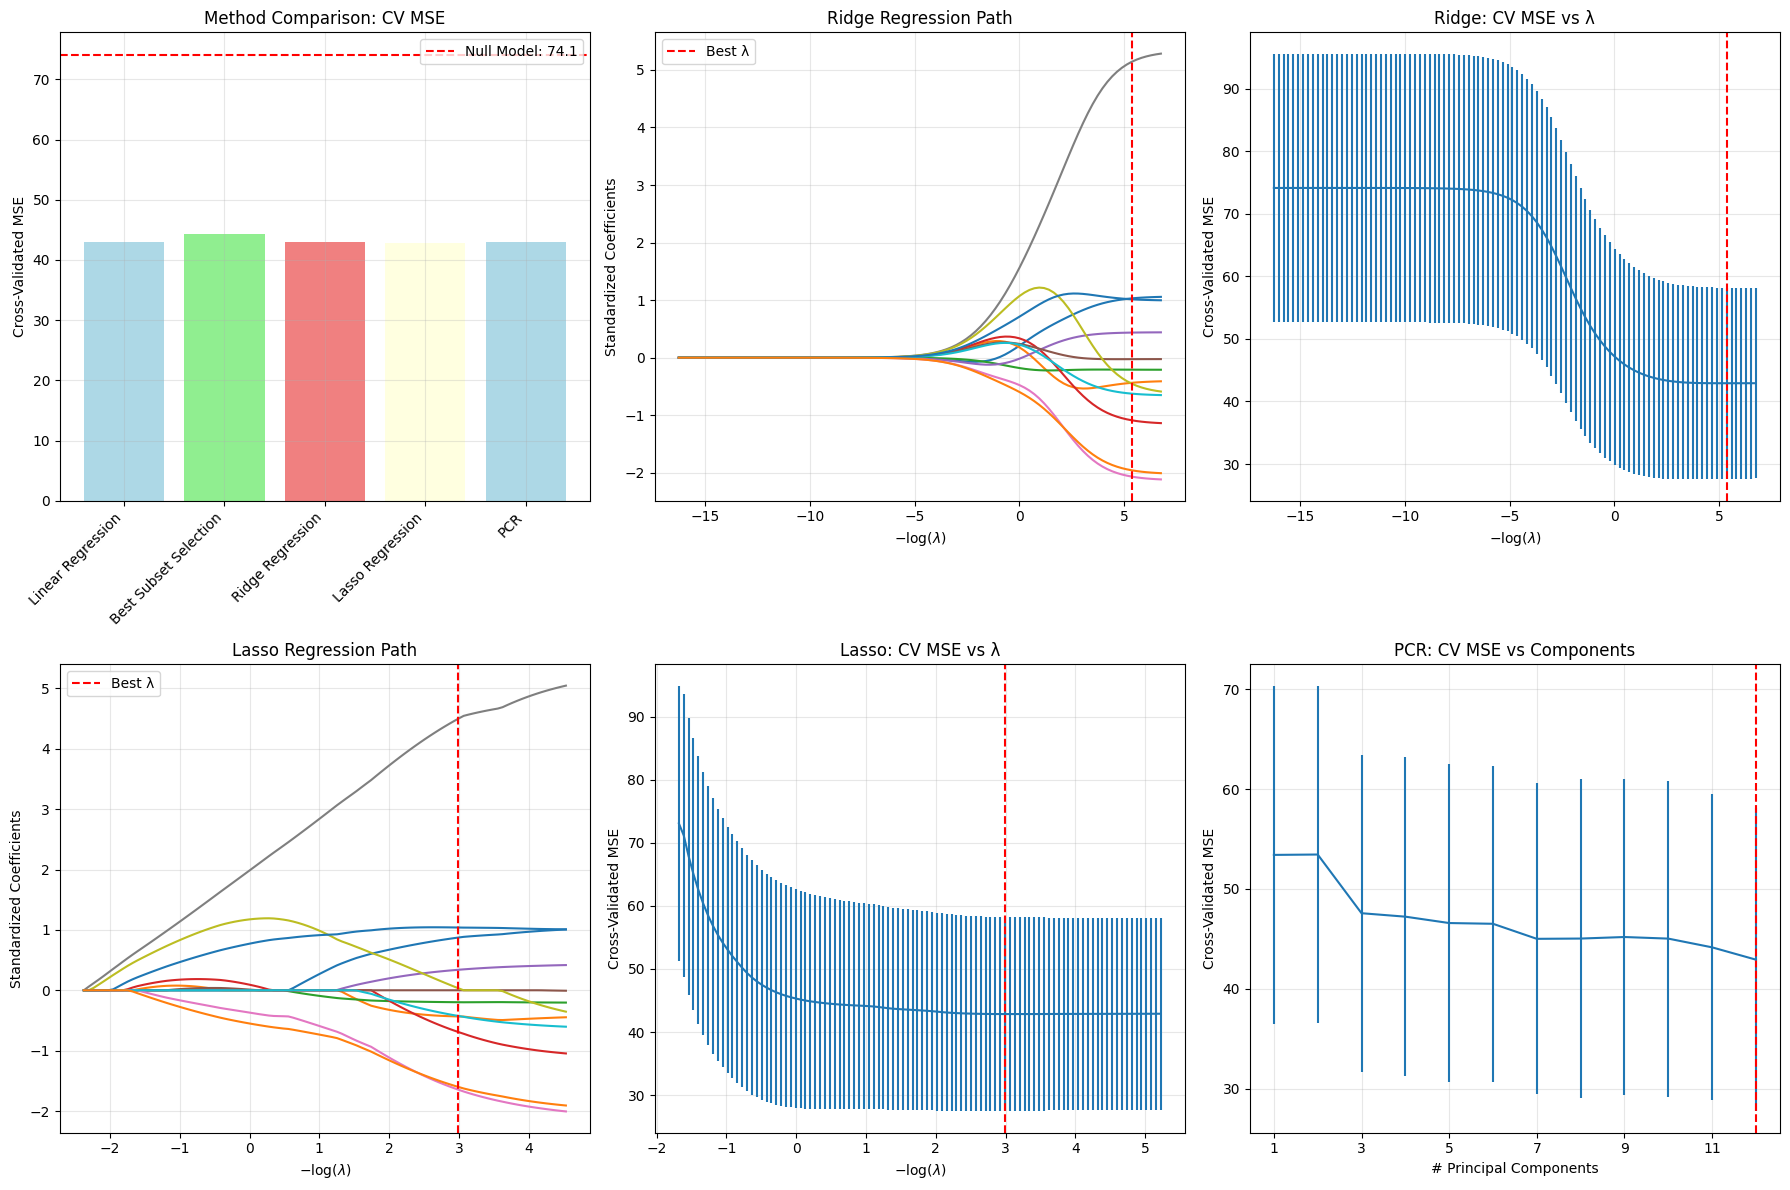

In [18]:
# Create comprehensive plots
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. CV Error Comparison
axes[0, 0].bar(range(len(methods)), cv_errors, color=['lightblue', 'lightgreen', 'lightcoral', 'lightyellow'])
axes[0, 0].axhline(y=null_mse, color='red', linestyle='--', label=f'Null Model: {null_mse:.1f}')
axes[0, 0].set_xticks(range(len(methods)))
axes[0, 0].set_xticklabels(methods, rotation=45, ha='right')
axes[0, 0].set_ylabel('Cross-Validated MSE')
axes[0, 0].set_title('Method Comparison: CV MSE')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Ridge Path
axes[0, 1].plot(soln_path.index, soln_path.values)
axes[0, 1].axvline(-np.log(tuned_ridge.alpha_), color='red', linestyle='--', label=f'Best λ')
axes[0, 1].set_xlabel('$-\\log(\\lambda)$')
axes[0, 1].set_ylabel('Standardized Coefficients')
axes[0, 1].set_title('Ridge Regression Path')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Ridge CV Error
axes[0, 2].errorbar(-np.log(lambdas), tuned_ridge.mse_path_.mean(1),
                    yerr=tuned_ridge.mse_path_.std(1) / np.sqrt(K))
axes[0, 2].axvline(-np.log(tuned_ridge.alpha_), color='red', linestyle='--')
axes[0, 2].set_xlabel('$-\\log(\\lambda)$')
axes[0, 2].set_ylabel('Cross-Validated MSE')
axes[0, 2].set_title('Ridge: CV MSE vs λ')
axes[0, 2].grid(True, alpha=0.3)

# 4. Lasso Path
axes[1, 0].plot(soln_path_lasso.index, soln_path_lasso.values)
axes[1, 0].axvline(-np.log(tuned_lasso.alpha_), color='red', linestyle='--', label=f'Best λ')
axes[1, 0].set_xlabel('$-\\log(\\lambda)$')
axes[1, 0].set_ylabel('Standardized Coefficients')
axes[1, 0].set_title('Lasso Regression Path')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 5. Lasso CV Error
axes[1, 1].errorbar(-np.log(tuned_lasso.alphas_), tuned_lasso.mse_path_.mean(1),
                    yerr=tuned_lasso.mse_path_.std(1) / np.sqrt(K))
axes[1, 1].axvline(-np.log(tuned_lasso.alpha_), color='red', linestyle='--')
axes[1, 1].set_xlabel('$-\\log(\\lambda)$')
axes[1, 1].set_ylabel('Cross-Validated MSE')
axes[1, 1].set_title('Lasso: CV MSE vs λ')
axes[1, 1].grid(True, alpha=0.3)

# 6. PCR CV Error
n_comp = param_grid['pca__n_components']
axes[1, 2].errorbar(n_comp, -grid_pcr.cv_results_['mean_test_score'],
                    grid_pcr.cv_results_['std_test_score'] / np.sqrt(K))
axes[1, 2].axvline(grid_pcr.best_params_['pca__n_components'], color='red', linestyle='--')
axes[1, 2].set_ylabel('Cross-Validated MSE')
axes[1, 2].set_xlabel('# Principal Components')
axes[1, 2].set_title('PCR: CV MSE vs Components')
axes[1, 2].set_xticks(n_comp[::2])
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**(c) Does your chosen model involve all of the features in the data
set? Why or why not?**

Lasso Regression, which have the lowest test MSE, suggested only 10 out of 12 features from dataset. It removed variables that contribute little to reducing prediction error.

This sparsity reduces model variance more than it increases bias, and that is why Lasso attained the lowest cross-validated MSE while discarding two features that were weakly predictive (and possibly collinear with others). These features are proportion of owner-occupied units built prior to 1940 and full-value property-tax rate per $10,000.